<a href="https://colab.research.google.com/github/harirkp006/MLOPS-TRAINING/blob/main/Kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1.8   

     target  cluster  
0   

array([[5.8       , 2.7       ],
       [6.82391304, 3.07826087],
       [5.00392157, 3.40980392]])

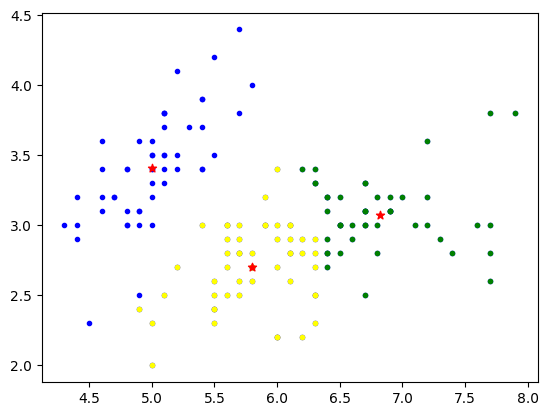

In [23]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

iris=load_iris()
data=iris.data
target=iris.target

df=pd.DataFrame(iris.data,columns=iris.feature_names)

df['target'] = iris.target

df[df.target==1].head()
df[df.target==2].head()


km = KMeans(n_clusters=3)
pred=km.fit_predict(df[['sepal length (cm)','sepal width (cm)']])
plt.scatter(df["sepal length (cm)"],df["sepal width (cm)"],marker=".",color = "blue")


df['cluster'] = pred
print(df)

df0 = df[df.cluster==0]
df1 = df[df.cluster==1]
df2 = df[df.cluster==2]
plt.scatter(df0['sepal length (cm)'],df0['sepal width (cm)'],marker=".",color="yellow")
plt.scatter(df1['sepal length (cm)'],df1['sepal width (cm)'],marker=".",color="green")


plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='red',marker='*',label='centroid')



km.cluster_centers_

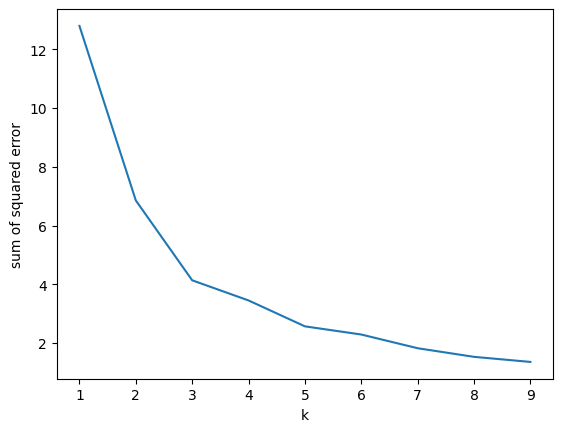

In [29]:
scaler = MinMaxScaler()
scaler.fit(df[['sepal width (cm)']])
df['sepal width (cm)'] = scaler.transform(df[['sepal width (cm)']])

scaler.fit(df[['sepal length (cm)']])
df['sepal length (cm)'] = scaler.transform(df[['sepal length (cm)']])

r=[]
k_rge=range(1,10)
for i in k_rge:
  km = KMeans(n_clusters=i)
  km.fit(df[['sepal length (cm)','sepal width (cm)']])
  r.append(km.inertia_)


plt.xlabel('k')
plt.ylabel('sum of squared error')
plt.plot(k_rge,r)